# Spike sorting in Spyglass (Spyglass pipeline, step 1 of 4)

This notebook runs the **Spyglass spike sorting pipeline version 1 (V1)** directly on ephys
data from the **Moore 2025 dataset** (Wood/Dudchenko lab) that has **already been inserted
into the Spyglass database**. It is the first of four notebooks; the remaining three add
automatic and manual curation and compare the results. See [`README.md`](README.md) for the
full chain.

This is different from the standalone SpikeInterface pipelines in
[`../pipelines_sorting/`](../pipelines_sorting/) (e.g. `Pipeline_H8000.ipynb`), which run
[`spikeinterface`](https://spikeinterface.readthedocs.io/) directly on raw Open Ephys folders and
never touch Spyglass. Here, the raw recording lives in the `Raw` table of the database, and every
stage of sorting is stored and tracked as a DataJoint table.

At the end we fetch **both** the new Spyglass-sorted result and the spike sorting that was
imported during the original NWB conversion, and compare their rasters, waveforms, and
provenance side by side.

Following the structure of `Pipeline_H8000.ipynb`, all of the choices you would normally
change are collected in a single **"parameters set manually"** cell near the top.

## Environment requirements

This notebook must be run in the **`spyglass` conda environment** created by the
[Spyglass quick-install instructions](https://github.com/LorenFrankLab/spyglass#installation)
and selected as the notebook kernel. That environment provides DataJoint, `spikeinterface`,
and the database client libraries.

In addition, the **`mountainsort5`** sorter must be installed into that environment:

```
pip install mountainsort5
```

Finally, the database connection settings are read from a `dj_local_conf.json` file (path
set in the next cell); point this at your own config if it lives elsewhere.

## Connect to the database

We load the DataJoint config (which holds the database connection info) and import the
Spyglass modules. Importing `spyglass.common` is what actually opens the connection.

In [1]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface as si
import pynwb
from pprint import pprint

# Load config for database connection info
dj_local_conf_path = "/Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json"
dj.config.load(dj_local_conf_path)

# Spyglass stores some parameters as native Python objects (dicts / lists) in the database;
# this flag lets DataJoint serialize and deserialize those blobs instead of rejecting them.
dj.config["enable_python_native_blobs"] = True

# General Spyglass imports (importing common connects to the database)
import spyglass.common as sgc
import spyglass.spikesorting.v1 as sgs
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename

/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-06-17 09:47:59,602][INFO]: DataJoint is configured from /Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json
[2026-06-17 09:47:59,632][INFO]: DataJoint 0.14.9 connected to root@localhost:3306
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Parameters set manually

Everything you might want to change for a different session, shank, or sorter lives here.

In [2]:
### Parameters set manually ###

# Session: the NWB copy that lives in the database (note the trailing underscore)
nwb_file_name = get_nwb_copy_filename("H3022-210806.nwb")  # -> "H3022-210806_.nwb"

# Which shank (sort group) and which epoch (interval) to sort
sort_group_id = 0
interval_list_name = "01"  # first wake epoch for this session

# Lab team that owns the sorting (any unique name)
team_name = "Wood/Dudchenko Lab"

# Pipeline parameters (these names refer to rows in the corresponding parameter tables)
preproc_param_name = "default"
sorter = "mountainsort5"        # requires: pip install mountainsort5
sorter_param_name = "default" 

## Optional: reset to re-run spike sorting

Re-running the pipeline below just re-inserts the same rows (Spyglass warns and skips
duplicates). If instead you want a clean re-sort -- e.g. after changing a parameter -- run
the next cell to delete **only this notebook's output** for the chosen session, sort group,
and interval: the `SpikeSortingRecording`, `SpikeSorting`, `CurationV1`, and their
`SpikeSortingOutput` entries. The original imported sorting and all other sessions are left
untouched.

DataJoint asks for confirmation before the cascade delete (the `safemode` prompt); type `yes`
to proceed. **Skip this cell entirely on a normal first run.**

In [3]:
# OPTIONAL RESET -- run only if you want to re-sort from scratch.
# Removes ONLY this notebook's output for the chosen session / sort group / interval
# (the SpikeSortingRecording, SpikeSorting, CurationV1, and their SpikeSortingOutput
# entries). The original imported sorting and every other session are left untouched.
reset_recording = sgs.SpikeSortingRecordingSelection & {
    "nwb_file_name": nwb_file_name,
    "sort_group_id": sort_group_id,
    "interval_list_name": interval_list_name,
    "preproc_param_name": preproc_param_name,
}

if reset_recording:
    recording_ids = reset_recording.fetch("recording_id")
    sorting_ids = (
        sgs.SpikeSortingSelection & [{"recording_id": r} for r in recording_ids]
    ).fetch("sorting_id")
    reset_merge_ids = (
        SpikeSortingOutput.CurationV1 & [{"sorting_id": s} for s in sorting_ids]
    ).fetch("merge_id")

    # Cascade-delete the recording -> sorting -> curation entries; this also removes the
    # CurationV1 part rows from the SpikeSortingOutput merge table.
    reset_recording.delete()

    # Sweep the now-orphaned SpikeSortingOutput master rows (their part was just deleted).
    (SpikeSortingOutput & [{"merge_id": m} for m in reset_merge_ids]).super_delete(
        warn=False, safemode=False
    )
else:
    print("Nothing to reset for this session / sort group / interval.")

Nothing to reset for this session / sort group / interval.


## Confirm the session is in the database

A quick check that the session we want to sort has been inserted. The raw ephys for this
session lives in the `Raw` table.

In [3]:
sgc.Session() & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,subject_id,institution_name,lab_name,session_id,session_description,session_start_time,timestamps_reference_time,experiment_description
H3022-210806_.nwb,H3022,University of Edinburgh,Wood/Dudchenko lab,210806,"Exploration, sleep and cue rotation",2021-08-06 11:34:07,2021-08-06 11:34:07,Basic properties of the head-direction system


## Lab team

All spike sorting results are linked to a team in the `LabTeam` table. Create it if it does
not already exist.

In [4]:
if not (sgc.LabTeam() & {"team_name": team_name}):
    sgc.LabTeam().create_new_team(
        team_name=team_name,
        team_members=[],
        team_description="Wood/Dudchenko lab spike sorting",
    )

## Define sort groups

Electrodes are grouped for sorting by the shank they sit on; electrodes in the same sort
group are sorted together.

Spyglass ships `SortGroup.set_group_by_shank`, but it assumes the electrode-group names are
numeric (it sorts them with `int(...)`). In this dataset the groups are named like
`probe1_shank1`, so that helper raises `ValueError: invalid literal for int()`. We therefore
build the sort groups manually below: one sort group per electrode group (shank), omitting
bad channels, with the reference taken from each shank's `original_reference_electrode`
(here `-1`, i.e. no reference). This session uses a single-shank probe, so there is one sort
group (`sort_group_id = 0`).

In [5]:
# Build sort groups manually (one per electrode group / shank), omitting bad channels.
def set_sort_groups_by_electrode_group(nwb_file_name):
    electrodes = (
        sgc.Electrode & {"nwb_file_name": nwb_file_name} & {"bad_channel": "False"}
    ).fetch()
    electrode_group_names = sorted(np.unique(electrodes["electrode_group_name"]))

    sort_group_keys, sort_group_electrode_keys = [], []
    for sort_group_id, electrode_group_name in enumerate(electrode_group_names):
        in_group = electrodes["electrode_group_name"] == electrode_group_name
        reference_ids = np.unique(electrodes["original_reference_electrode"][in_group])
        assert len(reference_ids) == 1, (
            f"electrode group {electrode_group_name} has multiple reference electrodes"
        )
        sort_group_keys.append(
            {
                "nwb_file_name": nwb_file_name,
                "sort_group_id": sort_group_id,
                "sort_reference_electrode_id": int(reference_ids[0]),
            }
        )
        sort_group_electrode_keys.extend(
            {
                "nwb_file_name": nwb_file_name,
                "sort_group_id": sort_group_id,
                "electrode_group_name": electrode_group_name,
                "electrode_id": int(electrode_id),
            }
            for electrode_id in electrodes["electrode_id"][in_group]
        )

    sgs.SortGroup.insert(sort_group_keys, skip_duplicates=True)
    sgs.SortGroup.SortGroupElectrode.insert(
        sort_group_electrode_keys, skip_duplicates=True
    )


set_sort_groups_by_electrode_group(nwb_file_name)
sgs.SortGroup & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,sort_group_id,sort_reference_electrode_id the electrode to use for referencing
H3022-210806_.nwb,0,-1


## Select and extract the recording

`SpikeSortingRecordingSelection` combines a sort group + interval + preprocessing parameters
and generates a unique `recording_id`. Populating `SpikeSortingRecording` then filters and
references the recording (isolating the spike band) and stores the result as NWB. It also
records the recording's valid times as a new interval named by the `recording_id` -- that is
the interval we sort over below.

> ⏱️ **Long-running cell (~15 minutes).** Filtering and referencing the full recording is
> the slowest step in the notebook.

In [6]:
key = {
    "nwb_file_name": nwb_file_name,
    "sort_group_id": sort_group_id,
    "preproc_param_name": preproc_param_name,
    "interval_list_name": interval_list_name,
    "team_name": team_name,
}
sgs.SpikeSortingRecordingSelection.insert_selection(key)

ssr_pk = (sgs.SpikeSortingRecordingSelection & key).proj()
sgs.SpikeSortingRecording.populate(ssr_pk)

# Re-fetch the full key so it now carries the generated recording_id
key = (sgs.SpikeSortingRecordingSelection & key).fetch1()
sgs.SpikeSortingRecording & {"recording_id": key["recording_id"]}

[09:48:24][WARNING] Spyglass: Similar row(s) already inserted.


recording_id,analysis_file_name name of the file,object_id Object ID for the processed recording in NWB file,electrodes_id Object ID for the processed electrodes,hash Hash of the NWB file
e23b0255-c952-4c4b-8688-4ff6c315581b,H3022-210806_GL3SRK02VF.nwb,8f1370c6-dc47-4969-8aa7-003d8f3afe8d,3ea6ee44-329e-4a01-9ae5-ab81b7119646,e39442adb1949c0470420a81b0400773


## Run spike sorting

We pair the prepared recording with a sorter and its parameters in `SpikeSortingSelection`,
then populate `SpikeSorting`. We sort over the full extracted recording (the interval named
by the `recording_id`).

`SpikeSorterParameters.insert_default()` makes sure a `"default"` parameter set exists for
every available sorter, including `mountainsort5`.

> ⏱️ This cell runs `mountainsort5` and takes about a minute.

In [7]:
sgs.SpikeSorterParameters.insert_default()

sorting_key = {
    "recording_id": key["recording_id"],
    "sorter": sorter,
    "nwb_file_name": nwb_file_name,
    "interval_list_name": str(key["recording_id"]),  # the full extracted recording
    "sorter_param_name": sorter_param_name,
}
sgs.SpikeSortingSelection.insert_selection(sorting_key)

sss_pk = (sgs.SpikeSortingSelection & sorting_key).proj()
sgs.SpikeSorting.populate(sss_pk)

sgs.SpikeSorting & sorting_key

[09:48:26][INFO] Spyglass: Similar row(s) already inserted.
[09:48:26][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.


sorting_id,analysis_file_name name of the file,object_id Object ID for the sorting in NWB file,"time_of_sort in Unix time, to the nearest second"
62224b1f-3d21-498f-bdc3-02c7e398ce77,H3022-210806_66RLRMD00Y.nwb,402ee9f3-ab3a-482e-9339-ab6a8f89dfe1,1781707149


## Make the result available downstream

To expose a sorting to downstream pipelines, it is inserted into the `SpikeSortingOutput`
merge table. The entry point is `CurationV1`: we register the raw sorter output as
`curation_id = 0` and insert that into the merge table.

In [8]:
sorting_id = (sgs.SpikeSortingSelection & sorting_key).fetch1("sorting_id")

# Register the raw sorter output as curation_id = 0 (no curation applied)
sgs.CurationV1.insert_curation(sorting_id=sorting_id, description="raw sort, no curation")

curation_key = {"sorting_id": sorting_id, "curation_id": 0}
SpikeSortingOutput.insert(
    (sgs.CurationV1 & curation_key).fetch("KEY", as_dict=True), part_name="CurationV1"
)
SpikeSortingOutput.merge_view()

[09:48:31][INFO] Spyglass: Writing new NWB file H3022-210806_N677TE2AU1.nwb
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:738: MissingRequiredBuildWarning: NWBFile 'root' is missing required value for attribute 'source_script_file_name'.
  warnings.warn(msg, MissingRequiredBuildWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:738: MissingRequired

*merge_id      *source        *sorting_id    *curation_id   *nwb_file_name
+------------+ +------------+ +------------+ +------------+ +------------+
045b9965-9cea- ImportedSpikeS None           0              H4819-220929_.
048a2f6c-b630- ImportedSpikeS None           0              H4827-221210_.
0b425267-f081- ImportedSpikeS None           0              H4822-221023_.
0c353fbf-e6be- CurationV1     62224b1f-3d21- 2              None          
0f0b203d-5d95- ImportedSpikeS None           0              H3026-211004_2
13ae1d88-f0d2- ImportedSpikeS None           0              H3029-230510_.
16b94a6e-1155- ImportedSpikeS None           0              H4825-221124_.
18293671-bb23- ImportedSpikeS None           0              H3015-210416_1
1aa93663-216a- ImportedSpikeS None           0              H4826-221203_.
26a370c8-12ff- ImportedSpikeS None           0              H3023-210812_.
26c458e7-add2- ImportedSpikeS None           0              H3019-210618_1
30e9d5bf-aa2c- ImportedSp

## Comparing to the original imported sorting

The sorting that came in during the original NWB conversion is **not** gone -- it lives in a
**different part table** of the same merge table:

| Source | Merge-table part | How it got there |
| --- | --- | --- |
| This notebook (Spyglass V1) | `SpikeSortingOutput.CurationV1` | We ran the V1 pipeline above. Has a `sorter` and full provenance. |
| Original conversion | `SpikeSortingOutput.ImportedSpikeSorting` | Imported from the NWB `units` table. No `sorter`, no recording lineage. |

Because they are separate rows (each with its own `merge_id`), they are never conflated.
Below we fetch both and compare their spike rasters, unit waveforms, and provenance. The
original imported sorting is reached through the pre-existing `SortedSpikesGroup` named
`"all_units"`.

In [9]:
# --- Spyglass V1 sorting (spikeinterface object) ---
v1_sorting = sgs.SpikeSorting.get_sorting(sorting_key)
v1_unit_ids = v1_sorting.get_unit_ids()
# get_unit_spike_train(..., return_times=True) returns seconds relative to recording start
v1_spike_times = [
    v1_sorting.get_unit_spike_train(unit_id, return_times=True) for unit_id in v1_unit_ids
]

# --- Original imported sorting (absolute session time) ---
imported_group_key = (
    SortedSpikesGroup
    & {"nwb_file_name": nwb_file_name, "sorted_spikes_group_name": "all_units"}
).fetch1("KEY")
imported_spike_times, imported_unit_ids = SortedSpikesGroup().fetch_spike_data(
    imported_group_key, return_unit_ids=True
)
imported_spike_times = [np.asarray(times) for times in imported_spike_times]

# V1 spike times are relative to the start of the sorted epoch; imported times are in
# absolute session time. Align both to "seconds since the start of epoch 01" so they can be
# compared over the same window.
epoch_valid_times = (
    sgc.IntervalList
    & {"nwb_file_name": nwb_file_name, "interval_list_name": interval_list_name}
).fetch1("valid_times")
epoch_start_time = float(epoch_valid_times[0][0])
raster_duration = 100.0  # seconds from the start of the epoch to display

print(f"Spyglass V1: {len(v1_unit_ids)} units; imported: {len(imported_unit_ids)} units")

[2026-06-17 09:48:37,727][WARNING]: Skipped checksum for file with hash: b8116206-ce71-028e-7a4f-a0cf70b4edd3, and path: /Users/pauladkisson/Documents/CatalystNeuro/DudchenkoConv/Spyglass/analysis/H3022-210806/H3022-210806_GL3SRK02VF.nwb
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
[09:48:38][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)


Spyglass V1: 19 units; imported: 31 units


## Spike raster comparison

Both rasters over the same window (the first `raster_duration` seconds of epoch `01`). The
top panel is the sorting we just produced with Spyglass + `mountainsort5`; the bottom panel
is the sorting imported during the original conversion.

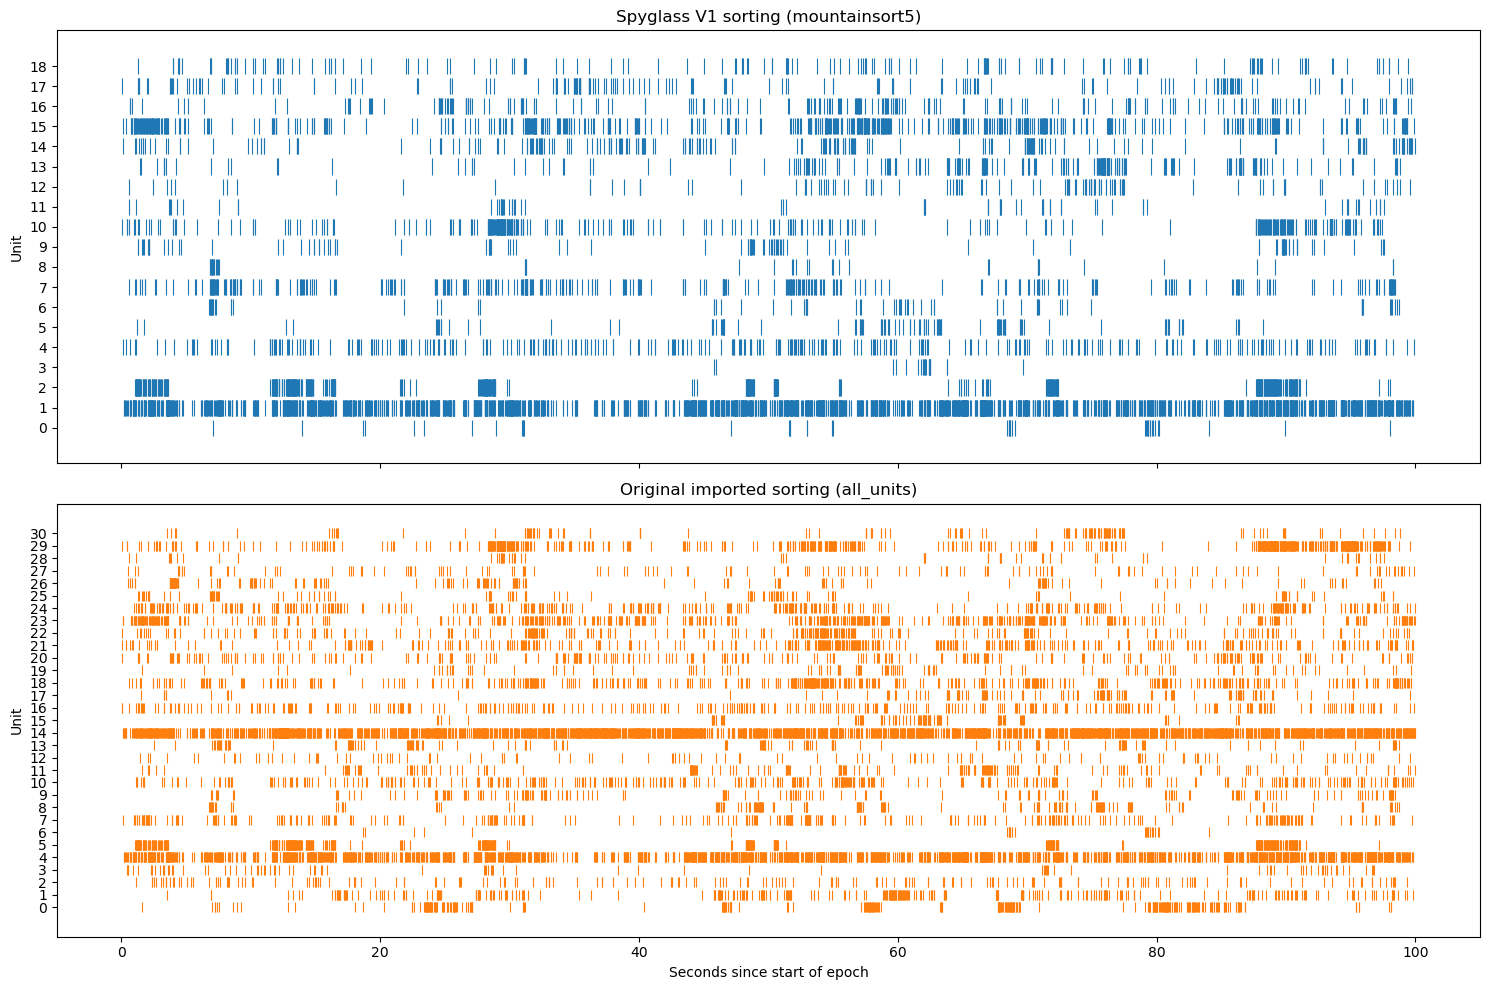

In [10]:
def window(spike_times_list, stop, offset=0.0):
    """Shift each unit's spike times by offset and keep those in [0, stop] seconds."""
    windowed = []
    for times in spike_times_list:
        relative = np.asarray(times) - offset
        windowed.append(relative[(relative >= 0.0) & (relative <= stop)])
    return windowed


fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].eventplot(
    window(v1_spike_times, raster_duration),
    linelengths=0.8, linewidths=0.8, colors="tab:blue",
)
axes[0].set_yticks(range(len(v1_unit_ids)))
axes[0].set_ylabel("Unit")
axes[0].set_title(f"Spyglass V1 sorting ({sorter})")

axes[1].eventplot(
    window(imported_spike_times, raster_duration, offset=epoch_start_time),
    linelengths=0.8, linewidths=0.8, colors="tab:orange",
)
axes[1].set_yticks(range(len(imported_unit_ids)))
axes[1].set_ylabel("Unit")
axes[1].set_xlabel("Seconds since start of epoch")
axes[1].set_title("Original imported sorting (all_units)")

plt.tight_layout()

## Unit waveform comparison

The mean waveform of each unit, shown on the channel where it is largest (peak channel). For
the Spyglass V1 sorting we extract waveforms from the filtered, referenced recording; for the
imported sorting we read the `waveform_mean` already stored in the NWB `units` table.

[2026-06-17 09:48:50,269][WARNING]: Skipped checksum for file with hash: b8116206-ce71-028e-7a4f-a0cf70b4edd3, and path: /Users/pauladkisson/Documents/CatalystNeuro/DudchenkoConv/Spyglass/analysis/H3022-210806/H3022-210806_GL3SRK02VF.nwb
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
[2026-06-17 09:48:51,086][WARNING]: Skipped checksum for file with hash: b8116206-ce71-028e-7a4f-a0cf70b4edd3, and path: /Users/pauladkisson/Documents/CatalystNeuro/DudchenkoConv/Spyglass/analys

extract waveforms shared_memory multi buffer:   0%|          | 0/1220 [00:00<?, ?it/s]

/var/folders/x6/29rr0k8916zddcpskyb57rz80000gn/T/ipykernel_35915/251673587.py:36: RuntimeWarning: All-NaN slice encountered
  peak_to_peak = np.nanmax(template, axis=0) - np.nanmin(template, axis=0)


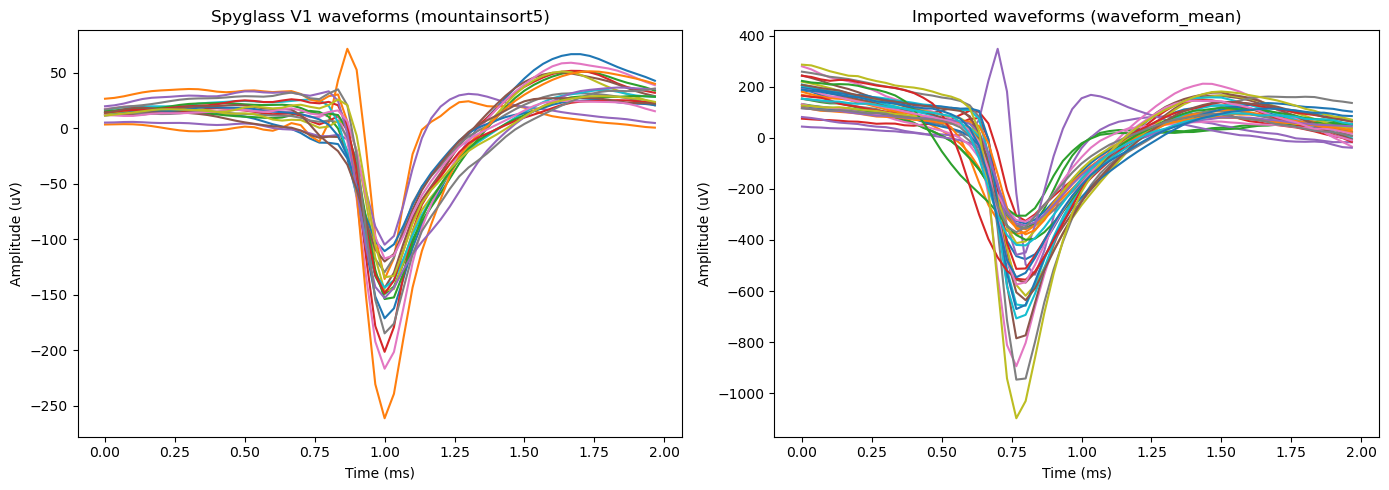

In [11]:
# --- Spyglass V1 waveforms: extract from the (filtered, referenced) recording ---
v1_recording = sgs.CurationV1.get_recording(curation_key)
v1_sorting_si = sgs.CurationV1.get_sorting(curation_key)
v1_waveform_extractor = si.extract_waveforms(
    recording=v1_recording,
    sorting=v1_sorting_si,
    mode="memory",
    ms_before=1.0,
    ms_after=1.0,
    max_spikes_per_unit=200,
    sparse=False,
)
v1_sampling_rate = v1_recording.get_sampling_frequency()
v1_templates = [
    v1_waveform_extractor.get_template(unit_id)  # shape (samples, channels)
    for unit_id in v1_sorting_si.get_unit_ids()
]

# --- Imported waveforms: read waveform_mean stored in the NWB units table ---
imported_object_id = (
    sgs.ImportedSpikeSorting & {"nwb_file_name": nwb_file_name}
).fetch1("object_id")
raw_nwb_path = (sgc.Nwbfile & {"nwb_file_name": nwb_file_name}).fetch1("nwb_file_abs_path")
with pynwb.NWBHDF5IO(raw_nwb_path, "r", load_namespaces=True) as io:
    imported_units = io.read().objects[imported_object_id].to_dataframe()
imported_templates = [np.asarray(wave) for wave in imported_units["waveform_mean"]]
imported_sampling_rate = float(imported_units["sampling_rate"].iloc[0])


def peak_channel_waveform(template):
    """Mean waveform on the channel with the largest peak-to-peak amplitude.

    The imported templates have all-NaN channels (electrodes dropped during the original
    sort), so we ignore NaNs when picking the peak channel.
    """
    peak_to_peak = np.nanmax(template, axis=0) - np.nanmin(template, axis=0)
    peak_channel = np.nanargmax(peak_to_peak)
    return template[:, peak_channel]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for template in v1_templates:
    waveform = peak_channel_waveform(template)
    time_ms = np.arange(waveform.size) / v1_sampling_rate * 1000.0
    axes[0].plot(time_ms, waveform)
axes[0].set_title(f"Spyglass V1 waveforms ({sorter})")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Amplitude (uV)")

for template in imported_templates:
    waveform = peak_channel_waveform(template)
    time_ms = np.arange(waveform.size) / imported_sampling_rate * 1000.0
    axes[1].plot(time_ms, waveform)
axes[1].set_title("Imported waveforms (waveform_mean)")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Amplitude (uV)")

plt.tight_layout()

## Provenance: one reason to run sorting in Spyglass

You could run `mountainsort5` yourself with SpikeInterface (that is what the standalone notebooks
in [`../pipelines_sorting/`](../pipelines_sorting/) do). One reason to run it *inside* Spyglass is
**provenance**: the database records exactly how every result was produced and lets you recover
that from the result alone.

Below, the Spyglass V1 sorting exposes its full lineage -- sort group, interval, team, and
the actual preprocessing and sorter parameter values. The imported sorting, by contrast,
records only a pointer into the NWB file: there is no record in the database of which sorter
or parameters produced it.

In [12]:
# --- Provenance of the Spyglass V1 sorting ---
# DataJoint records every upstream choice, so we can recover the actual parameter values
# (not just their names) from the sorting alone.
recording_selection = (
    sgs.SpikeSortingRecordingSelection & {"recording_id": key["recording_id"]}
).fetch1()
preproc_params = (
    sgs.SpikeSortingPreprocessingParameters
    & {"preproc_param_name": recording_selection["preproc_param_name"]}
).fetch1("preproc_params")
sorter_params = (
    sgs.SpikeSorterParameters
    & {"sorter": sorter, "sorter_param_name": sorter_param_name}
).fetch1("sorter_params")

print(
    f"sort group {recording_selection['sort_group_id']}, "
    f"interval '{recording_selection['interval_list_name']}', "
    f"team '{recording_selection['team_name']}'"
)
print(f"\npreprocessing parameters ('{recording_selection['preproc_param_name']}'):")
pprint(preproc_params)
print(f"\nsorter '{sorter}', parameters ('{sorter_param_name}'):")
pprint(sorter_params)

# --- "Provenance" of the imported sorting ---
# The imported result records no sorter or parameters -- only a pointer into the NWB file.
print("\nimported sorting -- no parameters recorded, only a pointer into the NWB file:")
display(sgs.ImportedSpikeSorting & {"nwb_file_name": nwb_file_name})

sort group 0, interval '01', team 'Wood/Dudchenko Lab'

preprocessing parameters ('default'):
{'frequency_max': 6000,
 'frequency_min': 300,
 'margin_ms': 5,
 'min_segment_length': 1,
 'seed': 0}

sorter 'mountainsort5', parameters ('default'):
{'detect_sign': -1,
 'detect_threshold': 5.5,
 'detect_time_radius_msec': 0.5,
 'filter': True,
 'freq_max': 6000,
 'freq_min': 300,
 'npca_per_channel': 3,
 'npca_per_subdivision': 10,
 'scheme': '2',
 'scheme1_detect_channel_radius': 150,
 'scheme2_detect_channel_radius': 50,
 'scheme2_max_num_snippets_per_training_batch': 200,
 'scheme2_phase1_detect_channel_radius': 200,
 'scheme2_training_duration_sec': 300,
 'scheme2_training_recording_sampling_mode': 'uniform',
 'scheme3_block_duration_sec': 1800,
 'snippet_T1': 20,
 'snippet_T2': 20,
 'snippet_mask_radius': 250,
 'whiten': True}

imported sorting -- no parameters recorded, only a pointer into the NWB file:


nwb_file_name name of the NWB file,object_id
H3022-210806_.nwb,00aaa3fa-0c60-4842-9b62-9c3a16290210


## Next step

The raw sort is now registered as `CurationV1` `curation_id = 0` and exposed in
`SpikeSortingOutput`. Continue with
[`Pipeline_Spyglass_AutomaticCuration.ipynb`](Pipeline_Spyglass_AutomaticCuration.ipynb)
(step 2 of 4) to curate it — automatically with quality metrics, and to export the sorting for
manual curation in the SpikeInterface GUI. See [`README.md`](README.md) for the full chain.